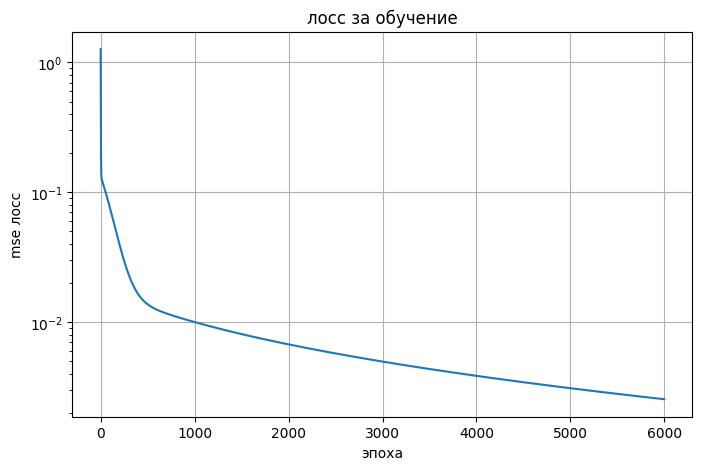

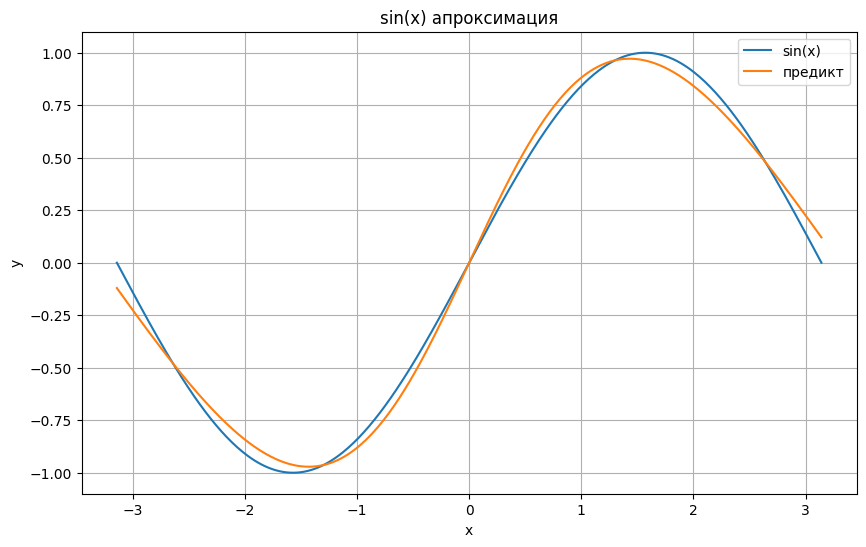

лосс в итоге: 0.0025391617981712017

x=-3.1416 реальный синус=-0.000000 предикт=-0.120733 |ошибка|= 0.120733
x=-1.5708 реальный синус=-1.000000 предикт=-0.962781 |ошибка|= 0.037219
x= 0.0000 реальный синус= 0.000000 предикт= 0.000000 |ошибка|= 0.000000
x= 1.5708 реальный синус= 1.000000 предикт= 0.962781 |ошибка|= 0.037219
x= 3.1416 реальный синус= 0.000000 предикт= 0.120733 |ошибка|= 0.120733


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from layer.layer import DenseLayer
from neural_network.seq_nn import SequentialNeuralNetwork
from activation_functions.tanh import Tanh
from loss_functions.mse_loss import MSELoss
np.random.seed(524)

x_train = np.linspace(-np.pi, np.pi, 256).reshape(-1, 1)
y_train = np.sin(x_train)

network = SequentialNeuralNetwork(
    modules=[
        DenseLayer(1, 32),
        Tanh(),
        DenseLayer(32, 32),
        Tanh(),
        DenseLayer(32, 1)
    ],
    loss=MSELoss()
)

history = network.fit(
    inputs=x_train,
    target=y_train,
    epochs=6000,
    learning_rate=0.01
)

x_test = np.linspace(-np.pi, np.pi, 400).reshape(-1, 1)
y_true = np.sin(x_test)
y_pred = network.predict(x_test)

control_x = np.array([
    [-np.pi],
    [-np.pi / 2],
    [0.0],
    [np.pi / 2],
    [np.pi]
])
control_true = np.sin(control_x)
control_pred = network.predict(control_x)

plt.figure(figsize=(8, 5))
plt.plot(history)
plt.yscale("log")
plt.xlabel("эпоха")
plt.ylabel("mse лосс")
plt.title("лосс за обучение")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(x_test.ravel(), y_true.ravel(), label="sin(x)")
plt.plot(x_test.ravel(), y_pred.ravel(), label="предикт")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sin(x) апроксимация")
plt.legend()
plt.grid(True)
plt.show()

print("лосс в итоге:", history[-1])
print()

for x_value, true_value, pred_value in zip(control_x.ravel(), control_true.ravel(), control_pred.ravel()):
    print(
        f"x={x_value: .4f} реальный синус={true_value: .6f} предикт={pred_value: .6f} |ошибка|={abs(true_value - pred_value): .6f}"
    )